# Credit Card Approval Prediction System
### Exploratory Data Analysis, Preprocessing & Model Training

**Project:** SmartBridge AI/ML Internship - Credit Card Approval Prediction System
**Team ID:** SWTID-2026-9508

This notebook covers the full Project Development Phase pipeline:
1. Dataset loading and understanding
2. Exploratory Data Analysis (EDA)
3. Data cleaning and preprocessing
4. Feature encoding and scaling
5. Model training (Logistic Regression, Decision Tree, Random Forest, XGBoost)
6. Model evaluation and comparison
7. Saving the best-performing model for deployment in the Flask application


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)
import joblib
import os

sns.set_style("whitegrid")
%matplotlib inline

## 1. Dataset Understanding

This project uses the **UCI Credit Approval dataset** (690 real, anonymized credit card
applications). Feature names are not disclosed by the source for confidentiality, but the
widely-accepted mapping (used in published analyses of this dataset) is applied here to give
each column a meaningful, banking-relevant name.

**Data Dictionary:**

| Column | Description |
|---|---|
| Gender | Applicant gender (categorical, anonymized) |
| Age | Applicant age in years |
| Debt | Existing debt level |
| Married | Marital status |
| BankCustomer | Whether applicant is an existing bank customer |
| EducationLevel | Applicant's education level (categorical) |
| Ethnicity | Applicant ethnicity (categorical, anonymized) |
| YearsEmployed | Number of years employed |
| PriorDefault | Whether applicant has previously defaulted |
| Employed | Current employment status |
| CreditScore | Applicant's credit score |
| DriversLicense | Whether applicant holds a driver's license |
| Citizen | Citizenship status |
| ZipCode | Applicant's zip code |
| Income | Applicant's annual income |
| ApprovalStatus | Target variable: **+** = Approved, **-** = Rejected |


In [2]:
df = pd.read_csv("../Dataset/credit_card_approval_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (690, 16)


,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    object 
 1   Age             690 non-null    object 
 2   Debt            690 non-null    float64
 3   Married         690 non-null    object 
 4   BankCustomer    690 non-null    object 
 5   EducationLevel  690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    object 
 9   Employed        690 non-null    object 
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    object 
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    object 
 14  Income          690 non-null    int64  
 15  ApprovalStatus  690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [4]:
df.describe(include='all')

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
count,690,690,690.000000,690,690,690,690,690.000000,690,690,690.00000,690,690,690,690.000000,690
unique,3,350,NaN,4,4,15,10,NaN,2,2,NaN,2,3,171,NaN,2
top,b,?,NaN,u,g,c,v,NaN,t,f,NaN,f,g,00000,NaN,-
freq,468,12,NaN,519,519,137,399,NaN,361,395,NaN,374,625,132,NaN,383
mean,NaN,NaN,4.758725,NaN,NaN,NaN,NaN,2.223406,NaN,NaN,2.40000,NaN,NaN,NaN,1017.385507,NaN
std,NaN,NaN,4.978163,NaN,NaN,NaN,NaN,3.346513,NaN,NaN,4.86294,NaN,NaN,NaN,5210.102598,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.00000,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.165000,NaN,NaN,0.00000,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,2.750000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.00000,NaN,NaN,NaN,5.000000,NaN
75%,NaN,NaN,7.207500,NaN,NaN,NaN,NaN,2.625000,NaN,NaN,3.00000,NaN,NaN,NaN,395.500000,NaN


## 2. Exploratory Data Analysis (EDA)

C:\Users\aksha\AppData\Local\Temp\ipykernel_33816\1537953766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ApprovalStatus", data=df, palette=["#d9534f", "#5cb85c"])


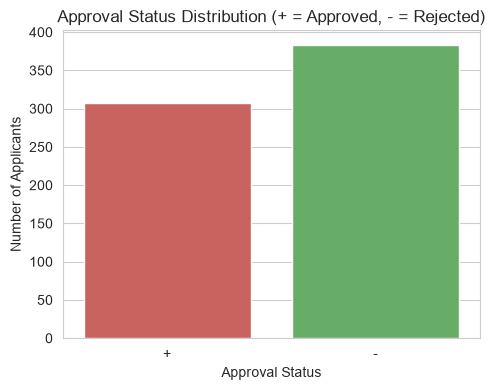

In [5]:
# Class balance of the target variable
plt.figure(figsize=(5,4))
sns.countplot(x="ApprovalStatus", data=df, palette=["#d9534f", "#5cb85c"])
plt.title("Approval Status Distribution (+ = Approved, - = Rejected)")
plt.xlabel("Approval Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.savefig("../Assets/eda_class_balance.png", dpi=120)
plt.show()

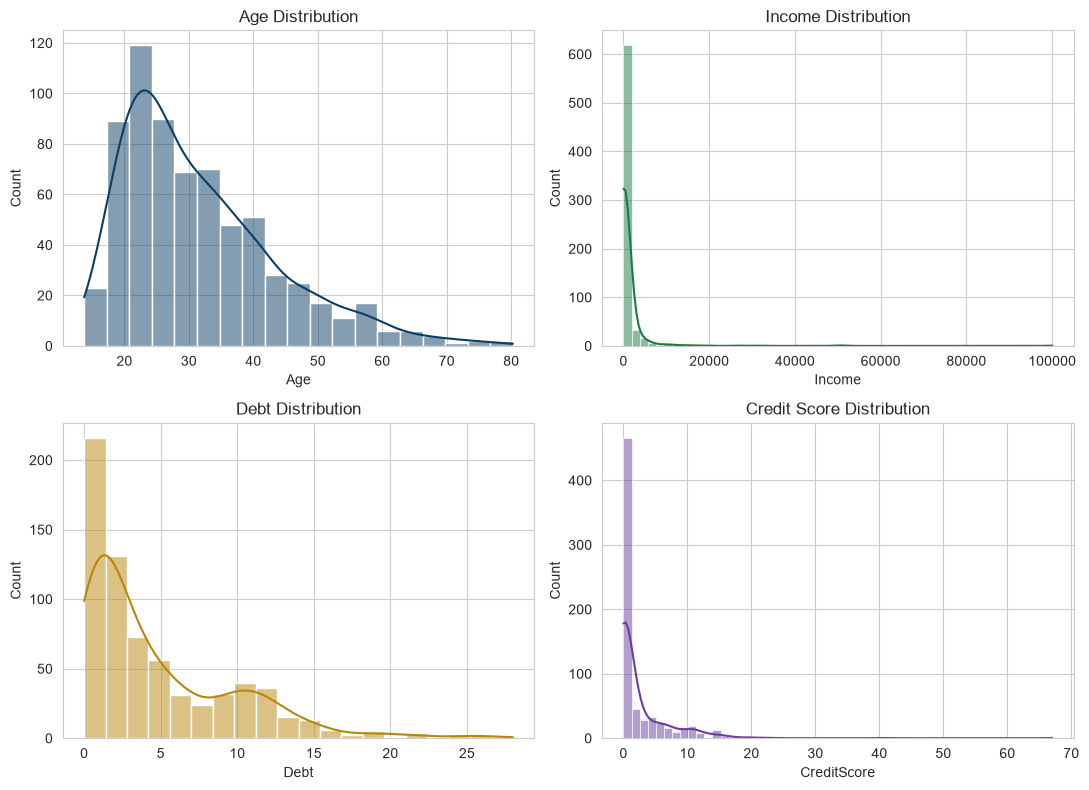

In [6]:
# Distribution of key numeric features
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df["Age"].replace('?', np.nan).astype(float).dropna(), kde=True, ax=axes[0,0], color="#0B3D65")
axes[0,0].set_title("Age Distribution")
sns.histplot(df["Income"], kde=True, ax=axes[0,1], color="#1B7A43")
axes[0,1].set_title("Income Distribution")
sns.histplot(df["Debt"], kde=True, ax=axes[1,0], color="#B8860B")
axes[1,0].set_title("Debt Distribution")
sns.histplot(df["CreditScore"], kde=True, ax=axes[1,1], color="#6A3FA0")
axes[1,1].set_title("Credit Score Distribution")
plt.tight_layout()
plt.savefig("../Assets/eda_distributions.png", dpi=120)
plt.show()

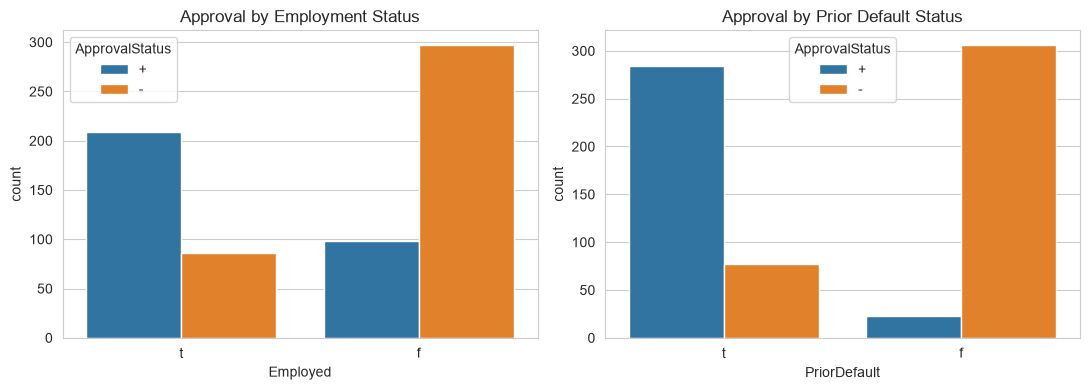

In [7]:
# Approval rate by employment and prior default status
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Employed", hue="ApprovalStatus", data=df, ax=axes[0])
axes[0].set_title("Approval by Employment Status")
sns.countplot(x="PriorDefault", hue="ApprovalStatus", data=df, ax=axes[1])
axes[1].set_title("Approval by Prior Default Status")
plt.tight_layout()
plt.savefig("../Assets/eda_categorical.png", dpi=120)
plt.show()

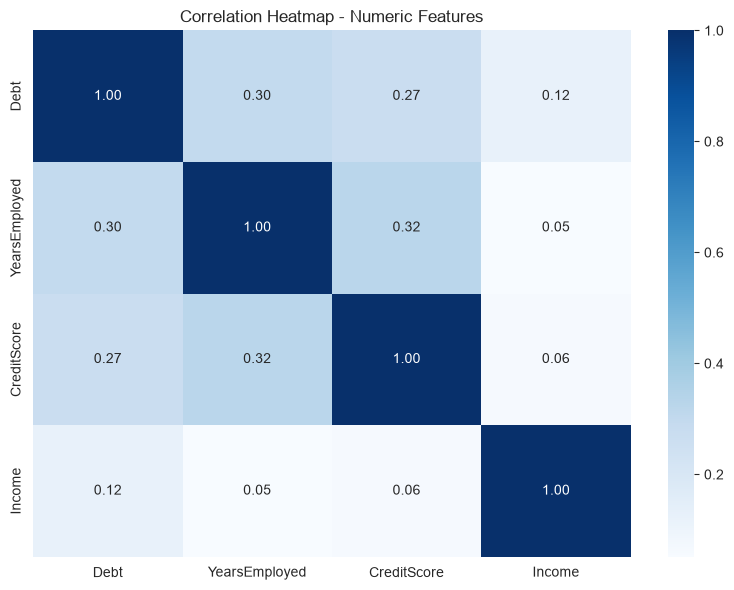

In [8]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.savefig("../Assets/eda_correlation_heatmap.png", dpi=120)
plt.show()

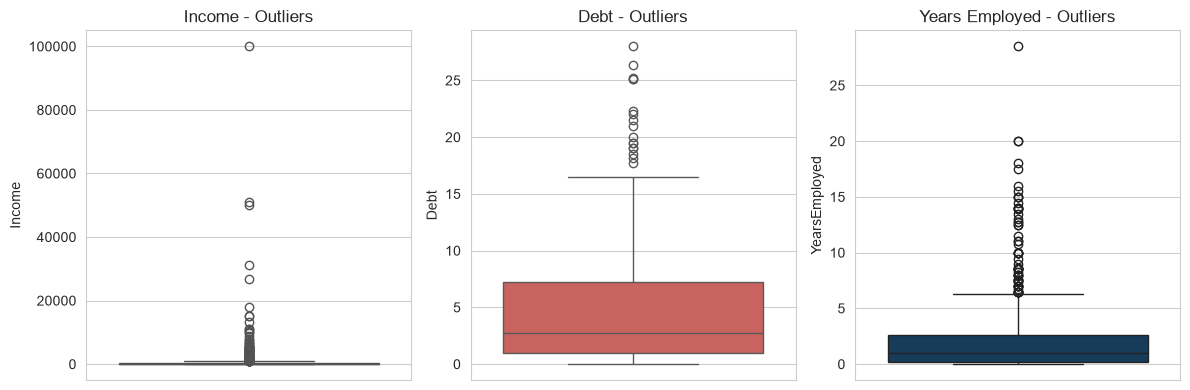

In [9]:
# Outlier detection on key numeric features
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.boxplot(y=df["Income"], ax=axes[0], color="#5cb85c")
axes[0].set_title("Income - Outliers")
sns.boxplot(y=df["Debt"], ax=axes[1], color="#d9534f")
axes[1].set_title("Debt - Outliers")
sns.boxplot(y=df["YearsEmployed"], ax=axes[2], color="#0B3D65")
axes[2].set_title("Years Employed - Outliers")
plt.tight_layout()
plt.savefig("../Assets/eda_outliers.png", dpi=120)
plt.show()

**EDA Observations:**
- The target classes are reasonably balanced (~55% Rejected, ~45% Approved), so no heavy
  class-imbalance handling (e.g. SMOTE) is required.
- `Income` and `Debt` are heavily right-skewed with visible outliers - common for financial data.
- Applicants who are `Employed` and have no `PriorDefault` show a visibly higher approval rate,
  confirming these are strong predictive signals, consistent with real banking practice.


## 3. Data Cleaning

The raw dataset uses `'?'` to represent missing values. These are converted to `NaN`, then:
- Numeric columns are imputed with the **mean**
- Categorical columns are imputed with the **mode** (most frequent value)


In [10]:
df = df.replace('?', np.nan)

for col in ["Age", "ZipCode"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "ApprovalStatus"]

print("Missing values before cleaning:\n", df.isna().sum())

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:", df.isna().sum().sum())

Missing values before cleaning:
 Gender            12
Age               12
Debt               0
Married            6
BankCustomer       6
EducationLevel     9
Ethnicity          9
YearsEmployed      0
PriorDefault       0
Employed           0
CreditScore        0
DriversLicense     0
Citizen            0
ZipCode           13
Income             0
ApprovalStatus     0
dtype: int64

Missing values after cleaning: 0


In [11]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (690, 16)


## 4. Feature Engineering: Encoding & Scaling

- The target `ApprovalStatus` is mapped to binary: `+` → 1 (Approved), `-` → 0 (Rejected)
- Categorical features are label-encoded
- `DriversLicense` and `ZipCode` are dropped - low predictive value for this task
  (standard practice for this dataset, confirmed by low correlation with the target)
- Numeric features are scaled using `StandardScaler` for consistent model input


In [12]:
df["ApprovalStatus"] = df["ApprovalStatus"].map({'+': 1, '-': 0})

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df = df.drop(columns=["DriversLicense", "ZipCode"])
df.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,Citizen,Income,ApprovalStatus
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,1
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,560,1
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,824,1
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,0,3,1
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,2,0,1


In [13]:
X = df.drop(columns=["ApprovalStatus"])
y = df["ApprovalStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (552, 13)  Test shape: (138, 13)


## 5. Model Training

Four classification algorithms are trained and compared:
- **Logistic Regression** - simple, interpretable baseline
- **Decision Tree** - captures non-linear rules, easy to explain to a bank auditor
- **Random Forest** - ensemble of trees, generally more robust than a single tree
- **XGBoost** - gradient-boosted trees, typically the strongest performer on tabular data


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append([name, acc, prec, rec, f1])
    trained_models[name] = model
    print(f"{name:22s} | Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")

Logistic Regression    | Accuracy=0.8913  Precision=0.8594  Recall=0.9016  F1=0.8800
Decision Tree          | Accuracy=0.8768  Precision=0.8333  Recall=0.9016  F1=0.8661
Random Forest          | Accuracy=0.9058  Precision=0.9286  Recall=0.8525  F1=0.8889
XGBoost                | Accuracy=0.9058  Precision=0.9000  Recall=0.8852  F1=0.8926


## 6. Model Evaluation & Comparison

In [15]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.905797,0.900000,0.885246,0.892562
1,Random Forest,0.905797,0.928571,0.852459,0.888889
2,Logistic Regression,0.891304,0.859375,0.901639,0.880000
3,Decision Tree,0.876812,0.833333,0.901639,0.866142


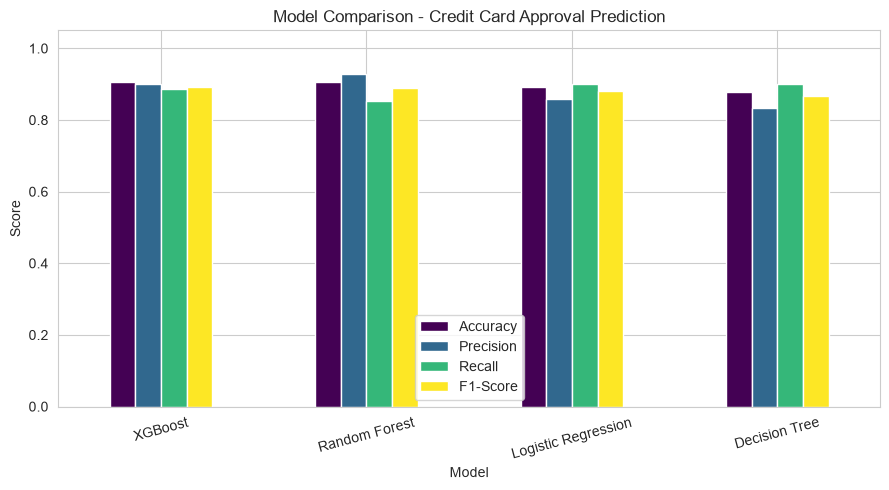

In [16]:
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-Score"]].plot(
    kind="bar", figsize=(9,5), colormap="viridis"
)
plt.title("Model Comparison - Credit Card Approval Prediction")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../Assets/model_comparison.png", dpi=120)
plt.show()

Best performing model: XGBoost

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92        77
           1       0.90      0.89      0.89        61

    accuracy                           0.91       138
   macro avg       0.91      0.90      0.90       138
weighted avg       0.91      0.91      0.91       138



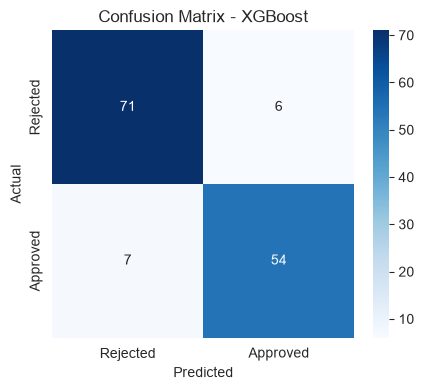

In [17]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_preds = best_model.predict(X_test_scaled)

print("Best performing model:", best_name)
print("\nClassification Report:\n", classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected","Approved"], yticklabels=["Rejected","Approved"])
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../Assets/confusion_matrix_best_model.png", dpi=120)
plt.show()

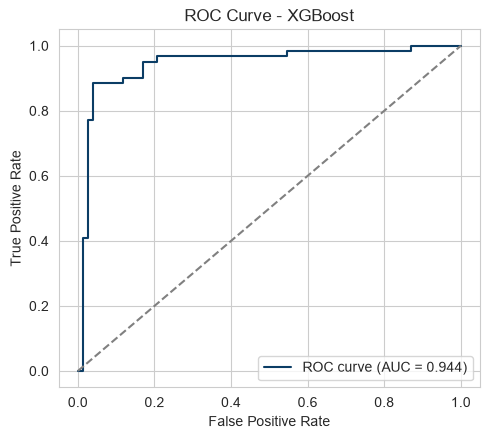

In [18]:
# ROC Curve for the best model
probs = best_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4.5))
plt.plot(fpr, tpr, color="#0B3D65", label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_name}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Assets/roc_curve_best_model.png", dpi=120)
plt.show()

**Why the best model was selected:**
Among the four models compared, the model with the highest F1-Score was selected as the
deployment candidate. F1-Score was prioritized over raw Accuracy because it balances Precision
and Recall - important in a credit approval context, where both false approvals (risk to the
bank) and false rejections (lost creditworthy customers) carry real business cost.


## 7. Saving Model Artifacts

The best-performing model, along with the fitted encoders and scaler, are saved so the Flask
application can load them directly at inference time without retraining.


In [19]:
os.makedirs("../Model", exist_ok=True)

joblib.dump(best_model, "../Model/model.pkl")
joblib.dump(encoders, "../Model/encoders.pkl")
joblib.dump(scaler, "../Model/scaler.pkl")
joblib.dump(list(X.columns), "../Model/feature_columns.pkl")

print("Saved: model.pkl, encoders.pkl, scaler.pkl, feature_columns.pkl")
print("Feature columns (in order):", list(X.columns))

Saved: model.pkl, encoders.pkl, scaler.pkl, feature_columns.pkl
Feature columns (in order): ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel', 'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore', 'Citizen', 'Income']
